## Methodology

### Setup

A ResNet mOdel is trained on 15,000 CIFAR-10 samples with SGD ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, cosine annealing, 15 epochs). The full parameter vector is snapshotted after each mini-batch update, yielding a trajectory of $T \approx 1{,}760$ iterates. Average-linkage hierarchical clustering with binary-search threshold selection partitions the trajectory into $K=40$ nodes, as described in the main analysis.

### Linear Loss Interpolation

For a user-specified set of nodes, the loss landscape is probed along the straight line in parameter space between the first and last iterate of each node:

$$\theta(\alpha) = (1-\alpha)\,\theta_0 + \alpha\,\theta_1, \quad \alpha \in [0,1]$$

The cross-entropy loss is evaluated at $N=100$ equally spaced points on this path using a fixed held-out subset of 2,000 test samples (no augmentation), ensuring fully reproducible loss values. At $\alpha=0$ and $\alpha=1$ the interpolated point coincides exactly with the actual iterate, so the endpoints of the interpolation curve are ground-truth losses.

### Interpretation

The absence of a pronounced hump in the interpolation curve between $\alpha=0$ and $\alpha=1$ indicates that no significant loss barrier exists along the straight path connecting the node's boundary iterates. This is consistent with the findings of Goodfellow et al.\ (2015), who report barrier-free linear interpolation from initialisation to solution, and with Xing et al.\ (2018), who show that SGD moves through valley-like regions of the loss surface throughout training. Flat or monotone interpolation curves within individual nodes further suggest that each cluster occupies a connected, approximately convex region of the loss landscape — structurally coherent with the linear chain topology of the quotient graph.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import copy
from torch.utils.data import Subset, DataLoader
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
import networkx as nx

torch.manual_seed(42)
np.random.seed(42)

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS       = 15
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
TRAIN_SIZE   = 15000
TEST_SIZE    = 5000
DEVICE       = "mps"  if torch.backends.mps.is_available() else \
               "cuda" if torch.cuda.is_available()         else "cpu"

# ── Graph ─────────────────────────────────────────────────────────────────────
TARGET_NODES = 40

# ── Interpolation ─────────────────────────────────────────────────────────────
N_INTERP       = 100    # points on the linear path
TEST_EVAL_SIZE = 2000   # test samples for loss evaluation


# ── Nodes to analyse (set after clustering) ───────────────────────────────────
ANALYSIS_NODES = None   # e.g. [0, 5, 12, 18, 24]

# ── Font sizes ────────────────────────────────────────────────────────────────
FS = dict(title=14, label=12, tick=10, legend=10)

print(f"Device: {DEVICE}  |  Epochs: {EPOCHS}  |  LR: {LR}  |  BS: {BATCH_SIZE}")
print(f"Target nodes: {TARGET_NODES}  |  N_INTERP: {N_INTERP} ")

Device: mps  |  Epochs: 15  |  LR: 0.1  |  BS: 128
Target nodes: 40  |  N_INTERP: 100  |  Noise σ: 0.007


In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = nn.Sequential(BasicBlock(16, 16, 1))
        self.layer2  = nn.Sequential(BasicBlock(16, 32, 2))
        self.layer3  = nn.Sequential(BasicBlock(32, 64, 2))
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        return self.fc(torch.flatten(self.avgpool(x), 1))


model    = ResNet20().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet-20  |  Parameters: {n_params:,}  |  "
      f"RAM/iterate (float16): {n_params*2/1e6:.2f} MB")

In [112]:
T_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

T_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

trainset = Subset(torchvision.datasets.CIFAR10(
    './data', train=True,  download=True, transform=T_train), range(TRAIN_SIZE))
testset  = Subset(torchvision.datasets.CIFAR10(
    './data', train=False, download=True, transform=T_test),  range(TEST_SIZE))

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Fixed test subset for all loss evaluations ────────────────────────────────
_ev_ds = Subset(torchvision.datasets.CIFAR10(
    './data', train=False, download=False, transform=T_test),
    range(TEST_EVAL_SIZE))
TEST_X, TEST_Y = next(iter(
    DataLoader(_ev_ds, batch_size=TEST_EVAL_SIZE, shuffle=False)))
TEST_X = TEST_X.to(DEVICE)
TEST_Y = TEST_Y.to(DEVICE)

print(f"Train: {len(trainset)}  |  Test: {len(testset)}  |  "
      f"Eval subset: {TEST_EVAL_SIZE}")

Files already downloaded and verified
Files already downloaded and verified
Train: 15000  |  Test: 5000  |  Eval subset: 2000


In [113]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, train_accs, test_accs = [], [], []
iterates = []

def snap(m):
    return np.concatenate([p.detach().cpu().numpy().ravel()
                           for p in m.parameters()]).astype(np.float16)

for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss, correct, total = 0., 0, 0
    for xb, yb in trainloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        iterates.append(snap(model))
        run_loss += loss.item() * xb.size(0)
        with torch.no_grad():
            correct += model(xb).argmax(1).eq(yb).sum().item()
        total += yb.size(0)

    trloss = run_loss / total
    tracc  = 100. * correct / total
    model.eval()
    c, t = 0, 0
    with torch.no_grad():
        for xb, yb in testloader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            c += model(xb).argmax(1).eq(yb).sum().item(); t += yb.size(0)
    teacc = 100. * c / t
    train_losses.append(trloss); train_accs.append(tracc); test_accs.append(teacc)
    scheduler.step()
    print(f"Epoch {epoch:2d}/{EPOCHS}  loss={trloss:.4f}  "
          f"train={tracc:.1f}%  test={teacc:.1f}%  n_iter={len(iterates)}")

iterates = np.stack(iterates).astype(np.float32)
T_TOTAL  = len(iterates)
SPE      = T_TOTAL // EPOCHS
print(f"\nTotal iterates: {iterates.shape}  |  {iterates.nbytes/1e6:.1f} MB")

Epoch  1/15  loss=1.8560  train=32.8%  test=36.4%  n_iter=118
Epoch  2/15  loss=1.5967  train=42.2%  test=43.5%  n_iter=236
Epoch  3/15  loss=1.4355  train=49.3%  test=50.9%  n_iter=354
Epoch  4/15  loss=1.3020  train=54.9%  test=52.2%  n_iter=472
Epoch  5/15  loss=1.1885  train=58.9%  test=55.4%  n_iter=590
Epoch  6/15  loss=1.1017  train=62.3%  test=57.4%  n_iter=708
Epoch  7/15  loss=1.0315  train=64.9%  test=59.6%  n_iter=826
Epoch  8/15  loss=0.9908  train=66.2%  test=61.9%  n_iter=944
Epoch  9/15  loss=0.9360  train=67.5%  test=64.5%  n_iter=1062
Epoch 10/15  loss=0.8933  train=69.3%  test=66.5%  n_iter=1180
Epoch 11/15  loss=0.8480  train=70.6%  test=66.9%  n_iter=1298
Epoch 12/15  loss=0.8068  train=71.9%  test=69.7%  n_iter=1416
Epoch 13/15  loss=0.7858  train=72.9%  test=70.3%  n_iter=1534
Epoch 14/15  loss=0.7637  train=73.3%  test=70.5%  n_iter=1652
Epoch 15/15  loss=0.7457  train=73.9%  test=70.3%  n_iter=1770

Total iterates: (1770, 78042)  |  552.5 MB


In [115]:
def find_eps_for_n(Z_, target, n_iter=80):
    lo, hi = Z_[:,2].min() * 0.1, Z_[:,2].max() * 1.5
    best_eps, best_diff = hi, np.inf
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        n   = fcluster(Z_, t=mid, criterion='distance').max()
        d   = abs(n - target)
        if d < best_diff: best_diff, best_eps = d, mid
        if n > target:    lo = mid
        elif n < target:  hi = mid
        else: return mid, n
    return best_eps, fcluster(Z_, t=best_eps, criterion='distance').max()


def build_and_relabel(iters_, labels_raw):
    n  = labels_raw.max() + 1
    G  = nx.DiGraph(); G.add_nodes_from(range(n))
    for t in range(len(labels_raw) - 1):
        u, v = int(labels_raw[t]), int(labels_raw[t+1])
        if G.has_edge(u, v): G[u][v]['weight'] += 1
        else:                G.add_edge(u, v, weight=1)
    for nid in range(n):
        times = np.where(labels_raw == nid)[0]
        G.nodes[nid]['size']      = len(times)
        G.nodes[nid]['mean_time'] = float(np.mean(times)) if len(times) else 0.
        G.nodes[nid]['times']     = times

    order  = sorted(G.nodes, key=lambda nd: G.nodes[nd]['mean_time'])
    remap  = {old: new for new, old in enumerate(order)}
    G2     = nx.DiGraph(); G2.add_nodes_from(range(n))
    for u, v, d in G.edges(data=True):
        u2, v2 = remap[u], remap[v]
        if G2.has_edge(u2, v2): G2[u2][v2]['weight'] += d['weight']
        else:                   G2.add_edge(u2, v2, weight=d['weight'])
    for old, new in remap.items():
        G2.nodes[new].update(G.nodes[old])
    return G2, np.array([remap[l] for l in labels_raw])


print("Computing distance matrix …")
dist_vec   = pdist(iterates, metric='euclidean')
print("Clustering (average linkage) …")
Z_sgd      = linkage(dist_vec, method='average')
eps_sgd, _ = find_eps_for_n(Z_sgd, TARGET_NODES)
G_sgd, labels_sgd = build_and_relabel(
    iterates, fcluster(Z_sgd, t=eps_sgd, criterion='distance') - 1)
N_NODES = G_sgd.number_of_nodes()
print(f"Graph: {N_NODES} nodes  (ε={eps_sgd:.5f})")

Computing distance matrix …
Clustering (average linkage) …
Graph: 40 nodes  (ε=1.53532)


In [116]:
# ── Set the nodes you want to analyse ────────────────────────────────────────
ANALYSIS_NODES = [ 15,16,17,18,38,39]   # ← adjust freely (0 to N_NODES-1)

# Validate
for nid in ANALYSIS_NODES:
    size = G_sgd.nodes[nid]['size']
    print(f"  Node {nid:3d}  |  n_iterates = {size}")

  Node  15  |  n_iterates = 19
  Node  16  |  n_iterates = 33
  Node  17  |  n_iterates = 26
  Node  18  |  n_iterates = 14
  Node  38  |  n_iterates = 131
  Node  39  |  n_iterates = 479


In [117]:
def eval_loss_flat(flat_vec, model_ref, x, y,
                   crit=nn.CrossEntropyLoss()):
    m   = copy.deepcopy(model_ref)
    ptr = 0
    with torch.no_grad():
        for p in m.parameters():
            n = p.numel()
            p.copy_(torch.from_numpy(
                flat_vec[ptr:ptr+n].reshape(p.shape)).to(DEVICE))
            ptr += n
    m.eval()
    with torch.no_grad():
        return crit(m(x), y).item()

In [118]:
def compute_interpolation(node_id, iters, labels,
                           model_ref, test_x, test_y,
                           n_interp):
    """
    Linear interpolation θ(α) = (1-α)·θ_first + α·θ_last
    plus test loss at every actual SGD iterate in the node.
    At α=0 and α=1 both curves share identical parameters.
    """
    times = np.sort(np.where(labels == node_id)[0])
    assert len(times) >= 2, f"Node {node_id} has < 2 iterates."

    theta_first = iters[times[0]].astype(np.float32)
    theta_last  = iters[times[-1]].astype(np.float32)

    t0, t1       = times[0], times[-1]
    actual_alpha = (times - t0) / max(t1 - t0, 1)

    alphas = np.linspace(0., 1., n_interp)

    print(f"  Node {node_id}: {n_interp} interpolation points …")
    interp_losses = np.array([
        eval_loss_flat((1-a)*theta_first + a*theta_last,
                       model_ref, test_x, test_y)
        for a in alphas])

    print(f"  Node {node_id}: {len(times)} actual iterate losses …")
    actual_losses = np.array([
        eval_loss_flat(iters[t].astype(np.float32),
                       model_ref, test_x, test_y)
        for t in times])

    return dict(
        node_id       = node_id,
        times         = times,
        n_iter        = len(times),
        alphas        = alphas,
        interp_losses = interp_losses,
        actual_alpha  = actual_alpha,
        actual_losses = actual_losses)


print(f"Computing interpolation for nodes {ANALYSIS_NODES} …\n")
results = {}
for nid in ANALYSIS_NODES:
    results[nid] = compute_interpolation(
        nid, iterates, labels_sgd,
        model, TEST_X, TEST_Y, N_INTERP)
print("\nDone.")

Computing interpolation for nodes [15, 16, 17, 18, 38, 39] …

  Node 15: 100 interpolation points …
  Node 15: 19 actual iterate losses …
  Node 16: 100 interpolation points …
  Node 16: 33 actual iterate losses …
  Node 17: 100 interpolation points …
  Node 17: 26 actual iterate losses …
  Node 18: 100 interpolation points …
  Node 18: 14 actual iterate losses …
  Node 38: 100 interpolation points …
  Node 38: 131 actual iterate losses …
  Node 39: 100 interpolation points …
  Node 39: 479 actual iterate losses …

Done.


In [ ]:

rng = np.random.default_rng(42)

for nid in sorted(results.keys()):
    r = results[nid]


    fig, ax = plt.subplots(figsize=(8, 5), dpi=160)

    ax.plot(r['alphas'], interp_l,
            '-', color='tomato', lw=2.2,
            label=f'Linear interpolation  ({N_INTERP} pts)')

    # Endpoint markers
    ax.scatter([0., 1.],
               [interp_l[0], interp_l[-1]],
               s=90, color='black', zorder=7,
               label='Endpoints (α = 0, α = 1)')

    ax.set_xlabel('Normalised position α  (0 = node start,  1 = node end)',
                  fontsize=FS['label'])
    ax.set_ylabel('Test loss', fontsize=FS['label'])
    ax.set_title(
        f'Node {nid}  |  n = {r["n_iter"]} iterates  ',
        fontsize=FS['title'], fontweight='bold')
    ax.legend(fontsize=FS['legend'], loc='best')
    ax.tick_params(labelsize=FS['tick'])
    ax.grid(alpha=.3)

    plt.tight_layout()
    plt.show()

'\nrng = np.random.default_rng(42)\n\nfor nid in sorted(results.keys()):\n    r = results[nid]\n\n\n    fig, ax = plt.subplots(figsize=(8, 5), dpi=160)\n\n    ax.plot(r[\'alphas\'], interp_l,\n            \'-\', color=\'tomato\', lw=2.2,\n            label=f\'Linear interpolation  ({N_INTERP} pts)\')\n\n    # Endpoint markers\n    ax.scatter([0., 1.],\n               [interp_l[0], interp_l[-1]],\n               s=90, color=\'black\', zorder=7,\n               label=\'Endpoints (α = 0, α = 1)\')\n\n    ax.set_xlabel(\'Normalised position α  (0 = node start,  1 = node end)\',\n                  fontsize=FS[\'label\'])\n    ax.set_ylabel(\'Test loss\', fontsize=FS[\'label\'])\n    ax.set_title(\n        f\'Node {nid}  |  n = {r["n_iter"]} iterates  \',\n        fontsize=FS[\'title\'], fontweight=\'bold\')\n    ax.legend(fontsize=FS[\'legend\'], loc=\'best\')\n    ax.tick_params(labelsize=FS[\'tick\'])\n    ax.grid(alpha=.3)\n\n    plt.tight_layout()\n    plt.show()\n    '

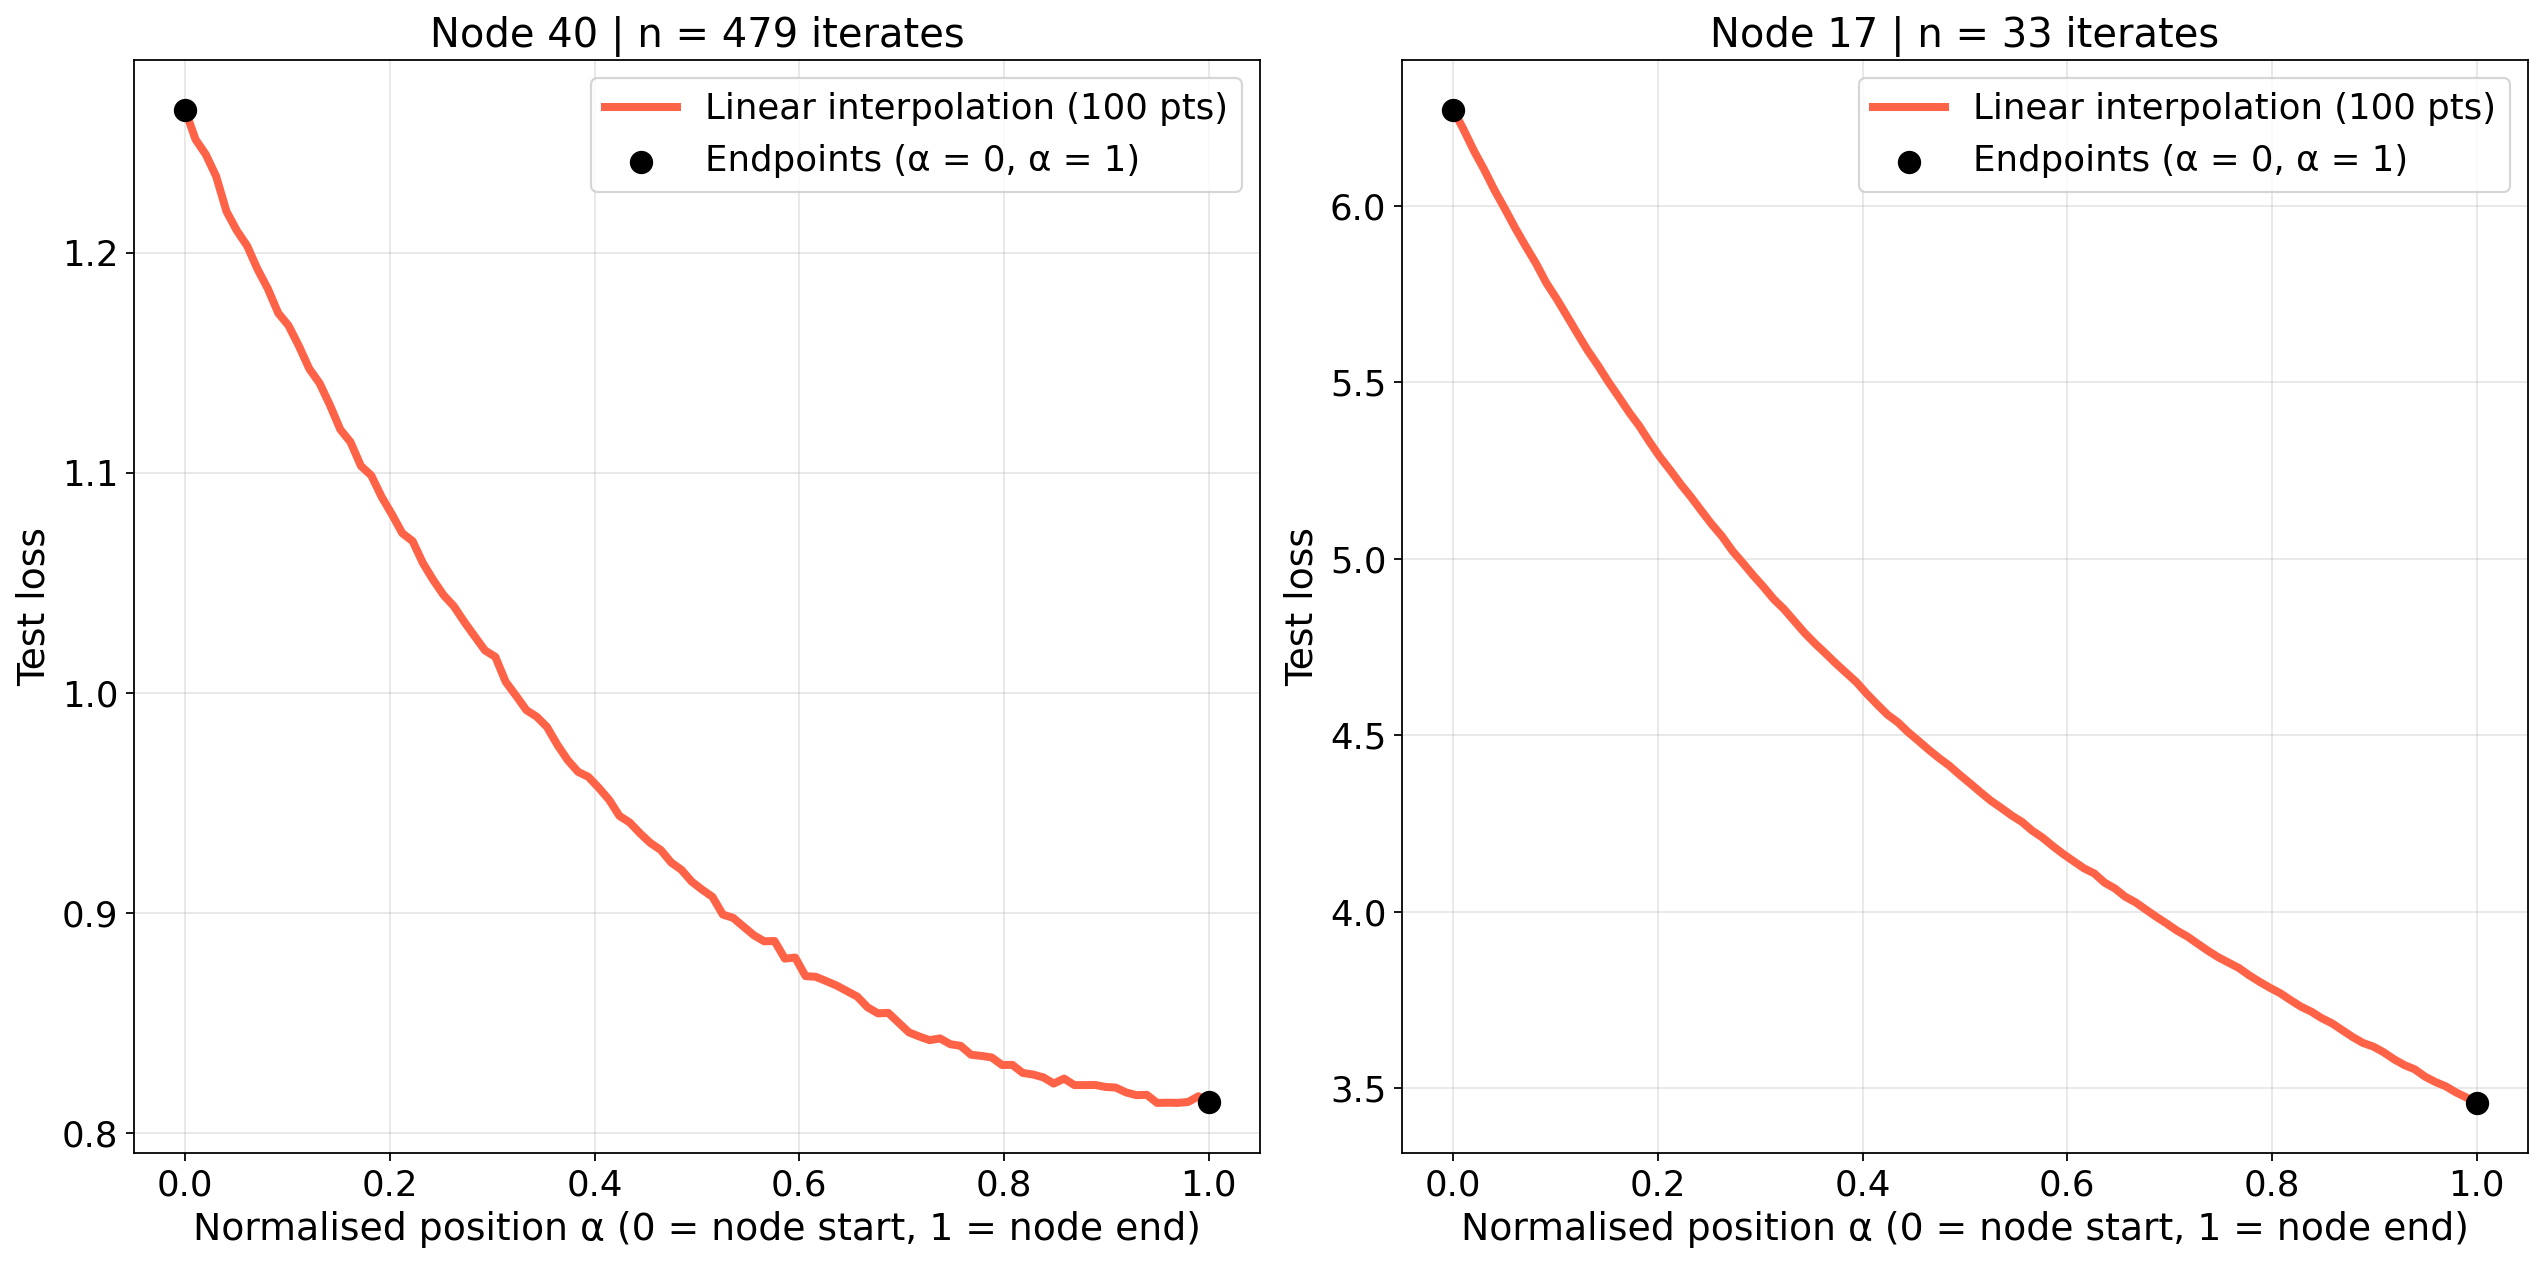

In [ ]:

# ── Adjust font sizes here ────────────────────────────────────────────────────
TITLE_FS  = 18
LABEL_FS  = 17
TICK_FS   = 16
LEGEND_FS = 16

rng = np.random.default_rng(42)

# Displayed node numbers
NODE_IDS = [40, 17]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    dpi=160
)

for ax, node_display in zip(axes, NODE_IDS):

    # results are internally numbered starting at 0
    nid = node_display - 1
    r = results[nid]


    ax.plot(
        r['alphas'],
        interp_l,
        '-',
        color='tomato',
        lw=3.6,
        label=f'Linear interpolation ({N_INTERP} pts)'
    )

    # Endpoint markers
    ax.scatter(
        [0., 1.],
        [interp_l[0], interp_l[-1]],
        s=90,
        color='black',
        zorder=7,
        label='Endpoints (α = 0, α = 1)'
    )

    ax.set_xlabel(
        'Normalised position α (0 = node start, 1 = node end)',
        fontsize=LABEL_FS
    )

    ax.set_ylabel(
        'Test loss',
        fontsize=LABEL_FS
    )

    ax.set_title(
        f'Node {node_display} | n = {r["n_iter"]} iterates',
        fontsize=TITLE_FS
    )

    ax.legend(
        fontsize=LEGEND_FS,
        loc='best'
    )

    ax.tick_params(
        axis='both',
        labelsize=TICK_FS
    )

    ax.grid(alpha=.3)

plt.tight_layout()
plt.show()